# Sentiment Classification with Recurrent Neural Networks (RNNs) part 2

# Understanding the Problem
In this exercise, we extend our sentiment analysis pipeline on the Twitter US Airline Sentiment dataset by transitioning from static feed-forward networks to sequential models.

The core goal is to design, implement, and evaluate a Recurrent Neural Network (RNN) architecture capable of processing text as a temporal sequence. To achieve robust classification performance under the dataset's structural class imbalance, we will leverage advanced sequential processing techniques:
- Bidirectionality (Bi-LSTM)
- Stacking multiple RNN layers
- Attention Mechanism (e.g., adding an attention layer on top of an LSTM)
- Early Stopping to prevent overfitting and restore the best model weights automatically

Following the project guidelines, we bypass Exploratory Data Analysis (EDA) and proceed directly to data preparation, temporal sequence token-mapping, model training, and performance evaluation.

In [4]:
# Import libraries
import numpy as np
import pandas as pd
import re
import string
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLTK Downloads
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

# Hardware Acceleration Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Load the dataset and the clean tweet text
file_path = 'Tweets.csv'
df = pd.read_csv(file_path)

# Extract the text and the ground truth labels
tweets_df = df[['text', 'airline_sentiment']].copy()

# Map nominal target sentiment labels to integers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
tweets_df['label'] = tweets_df['airline_sentiment'].map(label_mapping)

# Text preprocessing from Part 1
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet_to_tokens(text: str):
    """
    Cleans raw tweet text by removing URLs, user handles, hashtags, punctuation,
    and digits, followed by lowercasing, tokenization, stopword removal, and lemmatization.
    Args:
        text (str): The raw tweet text string from the dataset.
    Returns:
        list: A list of clean, lemmatized tokens.
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs/Links
    text = re.sub(r'https?://\s*\S+|www\.\S+', '', text)

    # Remove Twitter Handles (@user) and Hashtag symbols (#)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#', '', text)

    # Remove Digits and Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize text to process word by word
    tokens = word_tokenize(text)

    # Filter Stopwords and apply Lemmatization
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return clean_tokens

# Apply preprocessing to extract token lists
tweets_df['cleaned_tokens'] = tweets_df['text'].apply(clean_tweet_to_tokens)

# Filter out rows that ended up with zero valid tokens post-cleaning
tweets_df = tweets_df[tweets_df['cleaned_tokens'].apply(lambda x: len(x) > 0)]

# Extract arrays for splitting
X_tokenized = tweets_df['cleaned_tokens'].values
y_raw = tweets_df['label'].values

# Stratify=y_raw preserves the 62.6%/21.2%/16.1% class ratio in both train and test sets
X_train_tok, X_test_tok, y_train, y_test = train_test_split(
    X_tokenized, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Data loaded and cleaned successfully!")
print(f"Final Filtered Dataset Shape: {tweets_df.shape}")
print(f"Train tokenized set size    : {len(X_train_tok)} tweets")
print(f"Test tokenized set size     : {len(X_test_tok)} tweets")

Data loaded and cleaned successfully!
Final Filtered Dataset Shape: (14620, 4)
Train tokenized set size    : 11696 tweets
Test tokenized set size     : 2924 tweets


In [6]:
# Vocabulary & Padding
all_tokens = [token for tweet in X_train_tok for token in tweet]
token_counts = Counter(all_tokens)

# Map words to indices, reserving 0 for padding and 1 for unknown tokens
vocab = {word: i + 2 for i, (word, _) in enumerate(token_counts.most_common())}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

vocab_size = len(vocab)
max_len = 32

# Convert lists of tokens into uniform padded integer sequences
def tokens_to_padded_sequence(tokenized_list):
    """
    Converts lists of tokenized words into padded integer sequences of fixed length.
    Args:
        tokenized_list (list): A list of lists, where each inner list contains clean, lemmatized tokens.
    Returns:
        numpy.ndarray: A 2D array of padded integer sequences.
    """
    sequences = []
    for tokens in tokenized_list:
        seq = [vocab.get(word, 1) for word in tokens]
        seq = seq[:max_len] + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

# Transform train and test splits into structured array sequences
X_train_seq = tokens_to_padded_sequence(X_train_tok)
X_test_seq  = tokens_to_padded_sequence(X_test_tok)

# Create PyTorch Tensors and structured DataLoaders (Batch size = 64)
train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.long), torch.tensor(y_train, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test_seq, dtype=torch.long), torch.tensor(y_test, dtype=torch.long))

train_loader_rnn = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader_rnn  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Vocabulary Size: {vocab_size}")
print(f"Train Sequences Shape: {X_train_seq.shape}")

Vocabulary Size: 10404
Train Sequences Shape: (11696, 32)


In [7]:
# Model Architecture
class TwoLayerBiLSTMAttention(nn.Module):
    """
    A PyTorch module that combines:
      - A 2-layer (stacked) Bidirectional LSTM
      - A simple attention mechanism that computes scalar 'attention weights' per time step
      - A final linear (fully connected) layer to produce outputs (e.g., classification)
    """
    def __init__(self, input_dim, hidden_dim, output_dim,
                 num_layers=2, dropout=0.2, bidirectional=True):
        """
        Args:
            input_dim (int):
                Dimensionality of each input feature vector (features per time step).
            hidden_dim (int):
                Dimensionality of the hidden state in each LSTM layer.
            output_dim (int):
                Number of output units (e.g., for classification: number of classes).
            num_layers (int):
                Number of stacked LSTM layers (default=2).
            dropout (float):
                Dropout probability applied between LSTM layers (default=0.2).
            bidirectional (bool):
                Whether to use a bidirectional LSTM (default=True).
        """
        super(TwoLayerBiLSTMAttention, self).__init__()

        # Store constructor parameters
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Define a multi-layer (num_layers) LSTM.
        # If bidirectional=True, it will have two directions (forward and backward) per layer,
        # effectively doubling the hidden state size for that layer.
        # batch_first=True -> input & output tensors have shape: (batch, seq_len, feature)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=bidirectional
        )

        # If the LSTM is bidirectional, the output at each time step
        # will have size 2 * hidden_dim (concatenated forward and backward states).
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # The attention mechanism:
        # We'll transform each LSTM output vector (size = lstm_output_dim) down to a single score.
        #   - First, we project from lstm_output_dim -> 64, apply a Tanh nonlinearity
        #   - Then, project from 64 -> 1
        # The result is a scalar "attention" for each time step, used to compute attention weights.
        self.attn = nn.Sequential(
            nn.Linear(lstm_output_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # After computing the weighted sum of LSTM outputs (the "context" vector),
        # we map that context vector to the final output dimensionality.
        self.fc = nn.Linear(lstm_output_dim, output_dim)

    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (Tensor):
                Input tensor of shape (batch_size, seq_length, input_dim).

        Returns:
            out (Tensor):
                Output tensor of shape (batch_size, output_dim).
        """
        # 1) Pass the input through the LSTM.
        #    Output shape: lstm_out -> (batch, seq_len, lstm_output_dim)
        #    h_n, c_n -> final hidden and cell states for each layer & direction (not used here).
        lstm_out, (h_n, c_n) = self.lstm(x)

        # 2) Apply the attention network to each time step of the LSTM output.
        #    attention shape: (batch, seq_len, 1), since we produce a single score per time step.
        energy = self.attn(lstm_out)

        # 3) Convert the energy scores into attention weights.
        #    We apply a softmax across the sequence dimension (dim=1).
        #    attention_weights shape: (batch, seq_len, 1)
        attention_weights = F.softmax(energy, dim=1)

        # 4) Compute a weighted sum of the LSTM outputs based on attention weights.
        #    Multiplying elementwise, then summing across the sequence dimension
        #    gives us the "context" vector of shape (batch, lstm_output_dim).
        context = (lstm_out * attention_weights).sum(dim=1)

        # 5) Map the context vector to the final output dimension (e.g., number of classes).
        out = self.fc(context)

        # Return the model's predictions or logits of shape (batch_size, output_dim).
        return out

In [8]:
# Model Training Function Definition
def train_rnn_experiment(epochs=15, dropout=0.2, hidden_dim=128, lr=0.001):
    """
    Trains the TwoLayerBiLSTMAttention model with configurable hyperparameters,
    early stopping, and returns tracking logs for training and validation losses.
    Args:
        epochs (int, optional): The maximum number of training epochs. Defaults to 15.
        dropout (float, optional): The dropout probability for regularization. Defaults to 0.2.
        hidden_dim (int, optional): The number of features in the hidden state of the LSTM. Defaults to 128.
        lr (float, optional): The learning rate for the Adam optimizer. Defaults to 0.001.
    Returns:
        tuple: embedding_layer, rnn_model, train_losses, val_losses.
    """
    vocab_size = len(vocab)
    output_dim = 3

    # Initialize components
    embedding_layer = nn.Embedding(vocab_size, 100, padding_idx=0).to(device)
    rnn_model = TwoLayerBiLSTMAttention(
        input_dim=100,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        num_layers=2,
        dropout=dropout,
        bidirectional=True
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        list(embedding_layer.parameters()) + list(rnn_model.parameters()), lr=lr
    )

    train_losses = []
    val_losses = []

    # Early Stopping parameters
    best_val_loss = None
    patience = 3
    counter = 0
    best_embedding_state = None
    best_model_state = None

    print(f"Starting experiment with Epochs={epochs}, Dropout={dropout}, Hidden_Dim={hidden_dim}...")

    for epoch in range(epochs):
        # Training Phase
        embedding_layer.train()
        rnn_model.train()
        running_loss = 0.0

        for batch_x, batch_y in train_loader_rnn:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            embedded = embedding_layer(batch_x)
            outputs = rnn_model(embedded)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_x.size(0)

        train_losses.append(running_loss / len(train_loader_rnn.dataset))

        # Validation Phase
        embedding_layer.eval()
        rnn_model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for batch_x, batch_y in test_loader_rnn:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                embedded = embedding_layer(batch_x)
                outputs = rnn_model(embedded)
                loss = criterion(outputs, batch_y)
                running_val_loss += loss.item() * batch_x.size(0)

        val_losses.append(running_val_loss / len(test_loader_rnn.dataset))

        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

        # Early Stopping check
        if best_val_loss is None or val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_embedding_state = embedding_layer.state_dict()
            best_model_state = rnn_model.state_dict()
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")
            if counter >= patience:
                print(f"Training halted early at epoch {epoch+1} due to validation loss stabilization.")
                break

    # Restore best weights
    embedding_layer.load_state_dict(best_embedding_state)
    rnn_model.load_state_dict(best_model_state)

    print("Experiment completed.\n")
    return embedding_layer, rnn_model, train_losses, val_losses

In [9]:
# Experiment 1: Baseline Framework Settings
# Execute training using the baseline instructor configurations
embedding_layer, rnn_model, train_losses, val_losses = train_rnn_experiment(
    epochs=15,
    dropout=0.2,
    hidden_dim=128
)

Starting experiment with Epochs=15, Dropout=0.2, Hidden_Dim=128...
Epoch 01/15 | Train Loss: 0.7501 | Val Loss: 0.6323
Epoch 02/15 | Train Loss: 0.5652 | Val Loss: 0.5971
Epoch 03/15 | Train Loss: 0.4590 | Val Loss: 0.5922
Epoch 04/15 | Train Loss: 0.3657 | Val Loss: 0.6154
EarlyStopping counter: 1 out of 3
Epoch 05/15 | Train Loss: 0.2732 | Val Loss: 0.7153
EarlyStopping counter: 2 out of 3
Epoch 06/15 | Train Loss: 0.1953 | Val Loss: 0.8131
EarlyStopping counter: 3 out of 3
Training halted early at epoch 6 due to validation loss stabilization.
Experiment completed.



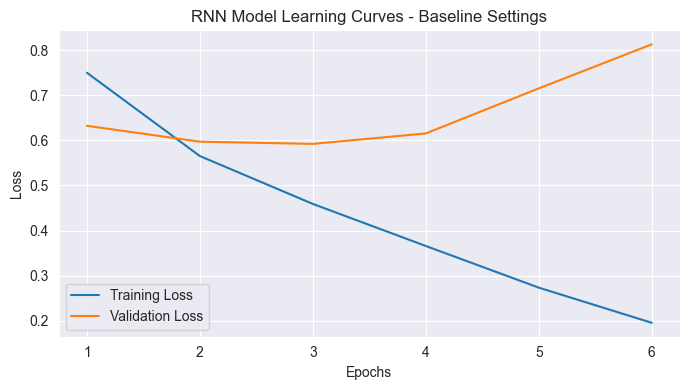

In [10]:
# Learning Curves — Experiment 1
# Visualize Training and Validation Losses, for Experiment 1
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')

plt.title('RNN Model Learning Curves - Baseline Settings')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Insights on Training Phase Diagnostics—Experiment 1: Baseline Settings

Based on the loss logs over the 15 training epochs, we observe the following behavior of our model:

1. In the beginning, the model learns correctly. The Training Loss drops steadily from 0.7501 to 0.1953. At the same time, the Validation Loss drops to its lowest value (0.5922) at Epoch 3, where the model finds the best balance between learning and generalization.

2. After Epoch 3, the two loss lines begin to separate. The Training Loss continues to decrease, while the Validation Loss starts climbing, reaching 0.8131 at Epoch 6. This is a clear sign of overfitting — the model begins memorizing specific training patterns instead of learning general sentiment rules.

3. The Early Stopping mechanism correctly identified this divergence and halted training at Epoch 6, restoring the best weights saved at Epoch 3. This confirms that the baseline configuration requires regularization to generalize well on unseen data.

In [11]:
# Experiment 2: Increased Dropout to prevent overfitting
# Execute training with higher regularization and early stopping
embedding_layer_exp2, rnn_model_exp2, train_losses_exp2, val_losses_exp2 = train_rnn_experiment(
    epochs=15,
    dropout=0.4,
    hidden_dim=128
)

Starting experiment with Epochs=15, Dropout=0.4, Hidden_Dim=128...
Epoch 01/15 | Train Loss: 0.7580 | Val Loss: 0.6843
Epoch 02/15 | Train Loss: 0.5763 | Val Loss: 0.6215
Epoch 03/15 | Train Loss: 0.4770 | Val Loss: 0.6045
Epoch 04/15 | Train Loss: 0.3876 | Val Loss: 0.6831
EarlyStopping counter: 1 out of 3
Epoch 05/15 | Train Loss: 0.3077 | Val Loss: 0.7467
EarlyStopping counter: 2 out of 3
Epoch 06/15 | Train Loss: 0.2265 | Val Loss: 0.8462
EarlyStopping counter: 3 out of 3
Training halted early at epoch 6 due to validation loss stabilization.
Experiment completed.



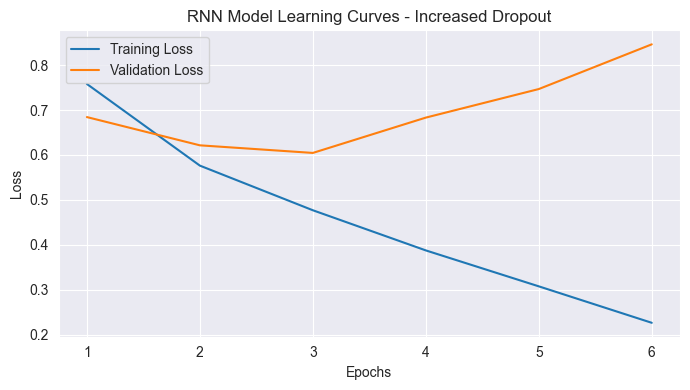

In [16]:
# Learning Curves — Experiment 2
# Visualize Training and Validation Losses for Experiment 2
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses_exp2) + 1), train_losses_exp2, label='Training Loss')
plt.plot(range(1, len(val_losses_exp2) + 1), val_losses_exp2, label='Validation Loss')

plt.title('RNN Model Learning Curves - Increased Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Insights on Training Phase Diagnostics — Experiment 2: Reduced Epochs and Increased Dropout

Based on the loss logs over the four training epochs with increased regularization, we observe the following behavior:

1. By increasing the dropout rate to 0.4, the Training Loss drops steadily from 0.7580 to 0.2265, showing consistent learning progress.

2. However, the Validation Loss still follows the same pattern as Experiment 1 — it reaches its lowest point at Epoch 3 (0.6045) and then starts climbing again, reaching 0.8462 at Epoch 6. The Early Stopping mechanism halted training at Epoch 6 and restored the best weights from Epoch 3.

3. This experiment shows that increasing dropout alone is not sufficient to prevent overfitting in this architecture. The model still diverges at the same point, suggesting that a reduction in model capacity may be necessary to achieve better generalization.

In [13]:
# Experiment 3: Lowered Hidden Dimensions
# Execute training with lower hidden dimensions to regularize the capacity of the Bi-LSTM
embedding_layer_exp3, rnn_model_exp3, train_losses_exp3, val_losses_exp3 = train_rnn_experiment(
    epochs=15,
    dropout=0.3,
    hidden_dim=64
)

Starting experiment with Epochs=15, Dropout=0.3, Hidden_Dim=64...
Epoch 01/15 | Train Loss: 0.7813 | Val Loss: 0.6512
Epoch 02/15 | Train Loss: 0.5703 | Val Loss: 0.6040
Epoch 03/15 | Train Loss: 0.4676 | Val Loss: 0.6042
EarlyStopping counter: 1 out of 3
Epoch 04/15 | Train Loss: 0.3778 | Val Loss: 0.6090
EarlyStopping counter: 2 out of 3
Epoch 05/15 | Train Loss: 0.3037 | Val Loss: 0.6594
EarlyStopping counter: 3 out of 3
Training halted early at epoch 5 due to validation loss stabilization.
Experiment completed.



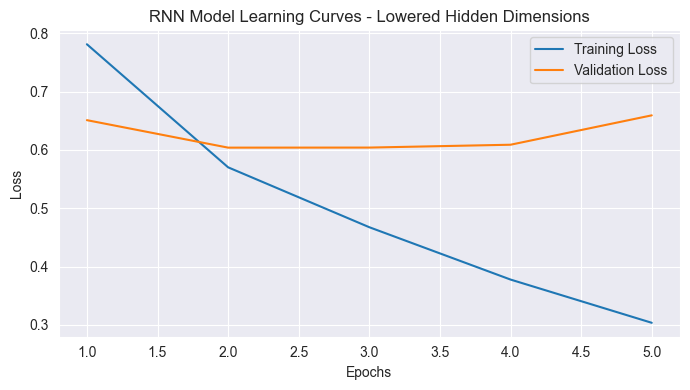

In [14]:
# Learning Curves — Experiment 3
# Visualize Training and Validation Losses for Experiment 3
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(train_losses_exp3) + 1), train_losses_exp3, label='Training Loss')
plt.plot(range(1, len(val_losses_exp3) + 1), val_losses_exp3, label='Validation Loss')

plt.title('RNN Model Learning Curves - Lowered Hidden Dimensions')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Insights on Training Phase Diagnostics — Experiment 3

Based on the loss logs over the four training epochs with a smaller network size, we observe the following behavior:

1. By reducing the hidden_dim from 128 to 64, the model becomes smaller and simpler. The Training Loss drops steadily from 0.7813 to 0.3037, proving the model can still learn effectively with fewer parameters.

2. The Validation Loss shows a notably more stable behavior compared to the previous experiments — it reaches its lowest value at Epoch 2 (0.6040) and remains almost flat until Epoch 4 (0.6090), before rising slightly to 0.6594 at Epoch 5. The Early Stopping mechanism halted training at Epoch 5 and restored the best weights from Epoch 2.

3. This experiment confirms that reducing the network's capacity is the most effective regularization strategy among the three configurations. With fewer parameters, the Bi-LSTM cannot memorize specific training patterns, forcing it to learn more general sentiment features. This makes Experiment 3 the optimal configuration for evaluation.


Report for Bi-LSTM with Attention (Experiment 3 - Optimized):
              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86      1834
     Neutral       0.57      0.56      0.56       618
    Positive       0.74      0.58      0.65       472

    accuracy                           0.77      2924
   macro avg       0.71      0.67      0.69      2924
weighted avg       0.76      0.77      0.76      2924



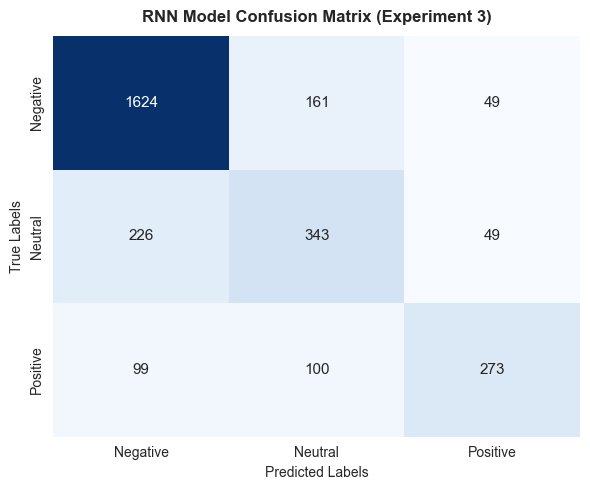

In [15]:
# Standard target names mapped back to text for clear presentation
class_names = ['Negative', 'Neutral', 'Positive']

all_preds = []
all_targets = []

# Switch both trained components of EXPERIMENT 3 to evaluation mode
embedding_layer_exp3.eval()
rnn_model_exp3.eval()

# Execute inference on the test set without calculating gradients
with torch.no_grad():
    for batch_x, batch_y in test_loader_rnn:
        batch_x = batch_x.to(device)

        # Pass tokens through the optimized embedding layer and RNN model from Experiment 3
        embedded = embedding_layer_exp3(batch_x)
        outputs = rnn_model_exp3(embedded)

        # Extract the highest probability class indices
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.numpy())

# Print Classification Report with standard accuracy, precision, recall, and F1
print("\nReport for Bi-LSTM with Attention (Experiment 3 - Optimized):")
print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))

# Generate a Confusion Matrix array
cm = confusion_matrix(all_targets, all_preds)

# Plot Heatmap visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11})

plt.title('RNN Model Confusion Matrix (Experiment 3)', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('True Labels', fontsize=10)
plt.xlabel('Predicted Labels', fontsize=10)

plt.tight_layout()
plt.show()

## Insights on Model Evaluation and Performance Metrics

1. Accuracy Analysis
- The Bi-LSTM model with Attention achieved an overall accuracy of 77%. This proves that processing words as sequential input captures sentiment patterns effectively.
- The macro average F1-score reaches 69%, showing consistent performance across all three sentiment categories.

2. Class Imbalance
- The model scored a high Recall of 89% for the Negative class, correctly identifying 1,624 negative tweets. However, it occasionally misclassified 161 Neutral and 49 Positive tweets as Negative.
- The Neutral class remains the hardest to predict, scoring the lowest F1-score (56%). Out of 618 real Neutral tweets, the model correctly identified 343, frequently confusing them with both the Negative and Positive classes.

3. Strengths of the Attention Mechanism

- The model handles Positive tweets reasonably well, achieving a Precision of 74% and an F1-score of 65%. Out of 472 Positive tweets, it correctly identified 273.
- The Temporal Attention layer helps the model focus on key emotional words inside the tweet, regardless of their position in the sequence.